In [ ]:
# Supervised 
# Binary Classification
# MultiClassClassification - online gaming behavior dataset

# Multilabel Classification
# -> allows us to classify with more than one target variable
# -> Several labels for outputs
# -> when predictions - input -> may belong to more than label

# Examples 
# Text Categorisation
# News Article Classification
# -> news article -> input -> may belong to multiple categories - politics, economy
# -> classifier -> can assign multiple labels to each new article 

# Images Tagging
# Social Media - Automatic Image Tagging
# -> Image can contain multiple objects - people, cars, trees
# -> tag that image multiple labels

# Medical Diagnosis :
# Predict Multiple Diseases
# -> diabetes, hypertension -> multiple diseases

In [ ]:
# Handle Imabalanced data in classification
# -> ML classification -> crucial step 
# -> credit card transactions data
# -> most of the transactions are valid transactions
# -> some transactions (very few in number) are fraudlent transactions
# -> Why deal?
# -> models tend to favor majority class - poor performance in identifying minority class
# -> Valid, Invalid -> predict that as invalid 

# Handling of Imbalanced Data
# -> Oversampling Technique (SMOTE)
# -> Undersampling Technique
# -> Ensemble Methods for Imbalanced data

In [1]:
# installation
!pip install -U imbalanced-learn

  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.3
    Uninstalling imbalanced-learn-0.12.3:
      Successfully uninstalled imbalanced-learn-0.12.3



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip show numpy pandas scikit-learn imbalanced-learn

Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYR

In [ ]:
!pip unistall -y numpy pandas scikit-learn imbalanced-learn

In [ ]:
pip install numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.1 imbalanced-learn==0.12.3

In [ ]:
python -m imblearn

In [13]:
# Explore dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,89630.0,0.030601,0.859108,0.290804,-0.591915,0.441892,-1.033405,1.016281,-0.190080,-0.066897,...,-0.251454,-0.537176,0.081516,-0.016869,-0.498699,0.142886,0.250215,0.097351,5.99,0
1,33404.0,1.042874,0.348936,-0.207597,2.215841,0.991928,1.349503,0.100767,0.451493,-0.739607,...,0.064860,0.193583,-0.007651,-1.379281,0.389286,0.225199,0.015614,-0.010651,15.16,0
2,57910.0,-1.549217,0.444995,1.953795,0.767481,1.249854,-0.439201,0.843048,0.145210,-1.561334,...,0.226098,0.136749,-0.178771,-0.013354,0.782533,-0.175391,-0.075909,0.058072,73.02,0
3,133413.0,-0.322340,0.969558,0.462259,-0.100560,-0.187871,-1.069206,0.454631,0.211302,-0.162835,...,0.164689,0.497732,-0.038204,0.420742,-0.191605,-0.333414,-0.032846,-0.010004,9.94,0
4,171524.0,1.990957,-1.984952,-1.014321,-1.265569,-1.371786,0.034195,-1.117904,0.061933,-0.828024,...,-0.416109,-0.844353,0.244993,0.716250,-0.264875,-0.387468,-0.015237,-0.036681,137.94,0


In [15]:
# Total length of the dataframe
len(df) # 2000

2000

In [17]:
# class distribution 
class_dist = df['Class'].value_counts()
print(class_dist)

Class
0    1974
1      26
Name: count, dtype: int64


In [ ]:
# Oversampling Technique
# -> used to balance the class distribution by increasing the number of minority class samples.
# -> can be done by duplicating existing samples or create synthetic samples
# SMOTE - Synthetic Minority Over-sampling Technique
# -> advanced method that generates new synthetic samples for the minority class
# -> How ?
# Select a random minority class sample
# Find its K nearest neighbors (k=5) 
# Choose one of the neighbors and create a synthetic sample along the line segment joining the original sample and the neighbor
# SMOTE - generate new samples
# Balance the dataset 

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [25]:
# Seperate features and target
X = df.drop(['Class','Time'], axis=1)
y = df['Class']

# Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Standarize the feature variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

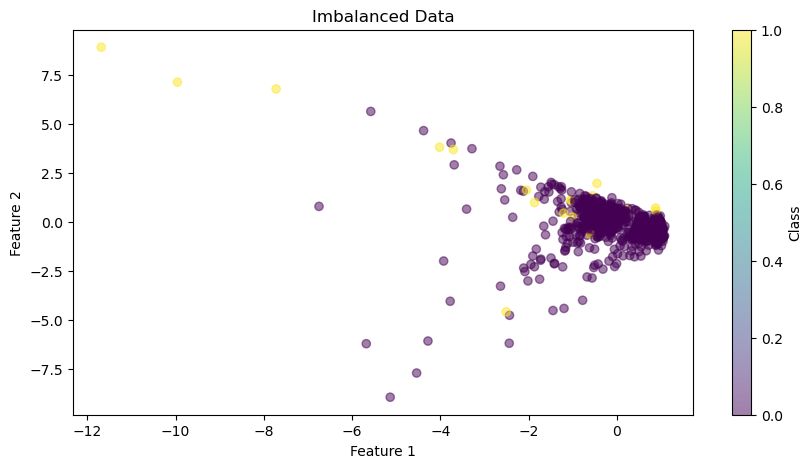

In [27]:
# Scatter plot for imabalanced data
plt.figure(figsize=(10,5))
plt.scatter(X_train_sc[:,0], X_train_sc[:,1], c=y_train, alpha=0.5, marker='o')
plt.title('Imbalanced Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')

In [29]:
# Apply SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

Text(0, 0.5, 'Feature 2')

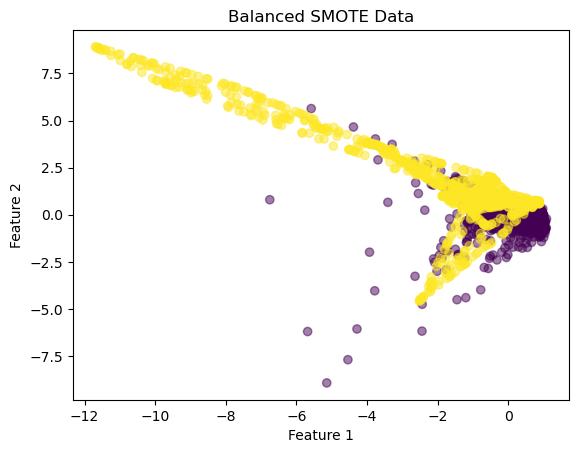

In [33]:
plt.scatter(X_train_smote[:,0], X_train_smote[:,1], c=y_train_smote, alpha=0.5, marker='o')
plt.title('Balanced SMOTE Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [35]:
# New training data - X_train_smote, y_train_smote
# Decision Tree Classifier 
from sklearn.metrics import confusion_matrix
dt_classifier =  DecisionTreeClassifier(max_depth=3,random_state=42) # limiting depth to 3

# Fit the data - X_train_smote, y_train_smote
dt_classifier.fit(X_train_smote, y_train_smote)

# Predict on training set and testing set
y_train_pred = dt_classifier.predict(X_train_smote)
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
y_test_pred = dt_classifier.predict(X_test_sc) # we not oversampled testing data
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print Testing and Training Accuracy
print(f'Train Accuracy : {train_accuracy}')
print(f'Testing Accuracy : {test_accuracy}')

# Print consfuion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

Train Accuracy : 0.9936548223350253
Testing Accuracy : 0.98375
[[779  13]
 [  0   8]]


In [37]:
# New Training data - X_train_smote, y_train_smote
# Decision Tree Classifier
dt_classifier =  DecisionTreeClassifier(max_depth=3,random_state=42) # limiting depth to 3

# Fit the data - X_train_smote, y_train_smote
dt_classifier.fit(X_train_smote, y_train_smote)

# Predict on training set and testing set
y_train_pred = dt_classifier.predict(X_train_smote)
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
y_test_pred = dt_classifier.predict(X_test_sc) # we not oversampled testing data
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print Testing and Training Accuracy
print(f'Train Accuracy : {train_accuracy}')
print(f'Testing Accuracy : {test_accuracy}')

# Print consfuion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

Train Accuracy : 0.9936548223350253
Testing Accuracy : 0.98375
[[779  13]
 [  0   8]]


In [ ]:
# Undersampling 
# -> majority class samples are randomly removed to achieve balance
# -> 1900 -> randomly select rows and remove it from majority
# -> Advs -> simple, reduces training time
# -> Diadvs -> Loss of Information
# -> Overfitting -> datset is small -> model might overfit to the remaining data

In [51]:
from imblearn.under_sampling import RandomUnderSampler

#undersampler = RandomUnderSampler(random_state=42)
#undersampler = RandomUnderSampler(sampling_strategy={0:40, 1:18},random_state=42)
undersampler = RandomUnderSampler(sampling_strategy=0.5,random_state=42)
# minority class will have 50% as many samples as majority class
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train_sc, y_train)

Text(0, 0.5, 'Feature 2')

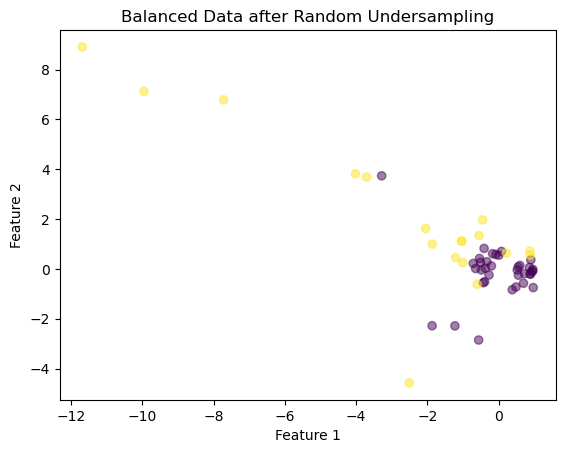

In [53]:
# Plot 

plt.scatter(X_train_undersampled[:,0], X_train_undersampled[:,1], c=y_train_undersampled, alpha=0.5, marker='o')
plt.title('Balanced Data after Random Undersampling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [57]:
# Decision Tree Classifier
dt_classifier =  DecisionTreeClassifier(random_state=42) 

# Fit the data - X_train_smote, y_train_smote
dt_classifier.fit(X_train_undersampled, y_train_undersampled)

# Predict on training set and testing set
y_train_pred = dt_classifier.predict(X_train_undersampled)
train_accuracy = accuracy_score(y_train_undersampled, y_train_pred)
y_test_pred = dt_classifier.predict(X_test_sc) # we not oversampled testing data
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print Testing and Training Accuracy
print(f'Train Accuracy : {train_accuracy}')
print(f'Testing Accuracy : {test_accuracy}')

# Print consfuion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

Train Accuracy : 1.0
Testing Accuracy : 0.97875
[[775  17]
 [  0   8]]


In [59]:
# undersampling
# oversampling

# Ensemle Methods
# -> combines the base models
# -> Random Forest -> DTC is base model

# imblearn -> Balanced Random Forest (BRF)
# -> ensemble method -> handle class imabalance
# -> BRF -> takes subset of majority class which is equal in size to the minority class
# -> special random forest classifier

from imblearn.ensemble import BalancedRandomForestClassifier

# ADvs -> improved performance minority class
# model is not biased towards majority class

In [61]:
# create it
# fit -> X_train_sc, y_train
brf_classifier = BalancedRandomForestClassifier(random_state=42)
brf_classifier.fit(X_train_sc, y_train)

# predict on test train
# Predict on training set and testing set
y_train_pred = brf_classifier.predict(X_train_sc)
train_accuracy = accuracy_score(y_train, y_train_pred)
y_test_pred = brf_classifier.predict(X_test_sc) # we not oversampled testing data
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print Testing and Training Accuracy
print(f'Train Accuracy : {train_accuracy}')
print(f'Testing Accuracy : {test_accuracy}')

# Print consfuion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

# evaluate - screenshots

Train Accuracy : 0.9908333333333333
Testing Accuracy : 0.99125
[[785   7]
 [  0   8]]
